# Content

- What are Ensemble Models?
- Types of Ensembles
- What is Bagging?

- Ensembling DTs - Random Forest
- How to introduce randomness?
- How to combine multiple DTs?

- How to validate RFs?
- OOB Score

- Bias Variance tradeoff
- Training a RF model
- RF Code Implementation
- Hyperparameters of RF

- Tuning the Hyperparameters (GridSearchCV)

- How to compute Feature Importances?

### Problem Statement:

<img src='https://drive.google.com/uc?id=1ip5dTv3RPqw3hplmMm7N7saCnBXYEVbV' width='800'>




In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter('ignore')

In [2]:
#!gdown 16KtxSt_QEGQvfluEaMls5cCHPwhRXgCk
#!gdown 19L3rYatfhbBL1r5MHrv-p_oM2wlvrhqk
#!gdown 1OHLKJwA3qZopKPvlKoRldM6BvA1A4dYF
#!gdown 1N7O_fWCTJLu8SIa_paKcDEzllgpMk8sK
#!gdown 12Bh2AN8LcZAlg20ehpQrEWccUDaSdsOG

In [3]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [4]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=7, max_depth=4)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=7)

In [5]:
print("Train accuracy: {:.2f}".format(tree_clf.score(X_train, y_train)*100))
print("Test accuracy: {:.2f}".format(tree_clf.score(X_test, y_test)*100))

Train accuracy: 88.57
Test accuracy: 85.05


<img src='https://drive.google.com/uc?id=1VYJVFsOG_L_rJgT3kr0XmTAxV7oFdnDD' width='800'>

### What are Ensembles?

Till now we have learned about different kinds of models.


<img src='https://drive.google.com/uc?id=1E1czWYEapMNjmuHc6xVGVvexkVH3EWAC' width='800'>

\
This is the key principle of ensembles.


### Types of Ensembles

There are mainly 4 types of ensemble learning techniques -

<img src='https://drive.google.com/uc?id=1oc_1-t1CjKxCcyEuXf9-BHDK1JiyudDy' width='800'>

### What is Bagging?

<img src='https://drive.google.com/uc?id=1jl5mMDD7lp8X3RO6CDNZSwDhxEjcDOtS' width='800'>

<img src='https://drive.google.com/uc?id=1RVh7qaXqMfBLUdCe4sMG77GPLyrYYDjf' width='800'>

### Random Forest

<img src='https://drive.google.com/uc?id=1Pw0-lZIJcIyMwOKmMYiZ3t6E-xFU2EK8' width='800'>


### Combining Decision Trees

<img src='https://drive.google.com/uc?id=1k8SZPy46Woawf63ubNKZ1YsWgkPbsHnf' width='800'>

### Randomness in model

<img src='https://drive.google.com/uc?id=16g74FTTbzSQRwpWbdpoasNIbNmTsS-tp' width='800'>

### Validating RF

After training, we cross validate each and every base learner.


<img src='https://drive.google.com/uc?id=1Jw7cYewCAbGFIBCPVx5j8DqqGzHsGc4u' width='800'>

<img src='https://drive.google.com/uc?id=1OVzFmQsTSqBte4SnEtdCtlBC8TYUu0C5' width='800'>

### Overall Performance

<img src='https://drive.google.com/uc?id=1e8xsEuAAYRLO2w6_K8REVsKqSHXugiTe' width='800'>

### OOB Score

We use the left over,
- ($n-m$) Out of Bag datapoints
- to calculate the **OOB score**.

#### Calculating OOB Score

<img src='https://drive.google.com/uc?id=1eRoy0GMC17NEvQ8gd5ADzudqpNLVrdYd' width='800'>

#### Using OOB Score

<img src='https://drive.google.com/uc?id=1N7xRDWUWCgJg34A6Bt4G5qB5zIIIY985' width='800'>



### Bias Variance Tradeoff

<img src='https://drive.google.com/uc?id=11wU7uMgnEiN8Gu6yuRW7QfWFxy_GwYjz' width='800'>

### Reducing Variance

<img src='https://drive.google.com/uc?id=1SGhVZ4FVtwGbZIPty8Mtrgi6RQe2EAdG' width='800'>

<img src='https://drive.google.com/uc?id=1PAptBxvyaJL3oy3BrFWvVUPwgJuhu9UP' width='800'>

### Training a RF model

<img src='https://drive.google.com/uc?id=13OW55gNN56JYp-Zy2aZNE2U6unO0t_NK' width='800'>

### Code Implementation - RF

Let's try to train a RF classifier for our problem.

In [6]:
X=pd.concat([X_train,X_test])
y=pd.concat([y_train,y_test])

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=7, max_depth=4, n_estimators=100)

In [8]:
from sklearn.model_selection import KFold, cross_validate

kfold = KFold(n_splits=10)
cv_acc_results = cross_validate(rf_clf, X, y, cv=kfold, scoring='accuracy', return_train_score=True)

print(f"K-Fold Accuracy Mean: \n Train: {cv_acc_results['train_score'].mean()*100:.2f} \n Validation: {cv_acc_results['test_score'].mean()*100:.2f}")
print(f"K-Fold Accuracy Std: \n Train: {cv_acc_results['train_score'].std()*100:.2f}, \n Validation: {cv_acc_results['test_score'].std()*100:.2f}")

K-Fold Accuracy Mean: 
 Train: 86.24 
 Validation: 84.97
K-Fold Accuracy Std: 
 Train: 0.29, 
 Validation: 2.42


As we can see that,
- the test accuracy has increased
- From **78%** to **84%**

### Optimizing RF

Remember hyperparameters?

Let's see the various hyperparameters of Random Forest.

<img src='https://drive.google.com/uc?id=1wtmXmxvsBxkKN33ssUYXfUCxkYEZuMnl' width='800'>

<img src='https://drive.google.com/uc?id=1dkcwOn0Hxzq4Au87w1mLiOQkA1KlVqIm' width='800'>

Similar to $λ$,
- which we used in linear & logistic regression
- for regularization.

\
<img src='https://drive.google.com/uc?id=1R-KBc7jEhA1S73OC30Pk3VEtOTHhrimj' width='800'>

There are other hyperparameters too in a RF.

Most of them are same ones that we saw in DT.

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

\
<center><img src='https://drive.google.com/uc?id=1vjUu4h9HLJhVvBg86dO9mV6vO-NW7OAT' height='225' width='950'>



```
QUIZ:

Which one of the following in not a hyperparameter of Random Forest?

A. Number of base learners
B. Depth of base learners
C. Sample size
D. Total number of columns

ANS: D. Total number of columns
```


```
QUIZ:

What is the use of the hyperparameter 'ccp_alpha'?

A. To set the column sampling ratio
B. To control underfitting or overfitting
C. To optimize the learning rate of RF
D. To set the depth of the base learners

ANS: B. To control underfitting or overfitting
```

### Hyperparameter Tuning

#### Grid Search

<img src='https://drive.google.com/uc?id=1u9SPZJrSZvXXuptA_SO_V4IemAuVTgwi' width='800'>

In [9]:
# Defining parameters -

params = {
          'n_estimators' : [100,200,300,400],
          'max_depth' : [3,5,10],
          'criterion' : ['gini', 'entropy'],
          'bootstrap' : [True, False],
          'max_features' : [8,9,10]
         }

In [10]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(estimator = RandomForestClassifier(),
                    param_grid = params,
                    scoring = 'accuracy',
                    cv = 3,
                    n_jobs=-1
                    )

In [11]:
grid.fit(X, y)

print("Best params: ", grid.best_params_)
print("Best score: ", grid.best_score_)

Best params:  {'bootstrap': False, 'criterion': 'gini', 'max_depth': 10, 'max_features': 10, 'n_estimators': 300}
Best score:  0.870748299319728


In [12]:
clf2 = RandomForestClassifier(random_state=7, bootstrap=False, criterion='gini',
                              max_depth=10, max_features=8, n_estimators=200)

kfold = KFold(n_splits=10)
cv_acc_results = cross_validate(clf2, X, y, cv=kfold, scoring='accuracy', return_train_score=True)

print(f"K-Fold Accuracy Mean: \n Train: {cv_acc_results['train_score'].mean()*100:.3f} \n Validation: {cv_acc_results['test_score'].mean()*100:.3f}")
print(f"K-Fold Accuracy Std: \n Train: {cv_acc_results['train_score'].std()*100:.3f}, \n Validation: {cv_acc_results['test_score'].std()*100:.3f}")

K-Fold Accuracy Mean: 
 Train: 99.101 
 Validation: 86.395
K-Fold Accuracy Std: 
 Train: 0.164, 
 Validation: 2.277


#### Randomized Search

<img src='https://drive.google.com/uc?id=1tozHZhVrVbLxIpa3aiOa_kaUj0KWOyS-' width='800'>

Let's try finding the optimal value of `ccp_alpha` for our model.

In [13]:
# Defining parameters -

from scipy.stats import uniform

params = {'ccp_alpha': uniform(loc=0, scale=0.4)}
# sample from uniform dist between 0 to 0.4

In [14]:
from sklearn.model_selection import RandomizedSearchCV

random = RandomizedSearchCV(estimator = RandomForestClassifier(random_state=7, bootstrap=False, criterion='gini',
                                                               max_depth=10, max_features=8, n_estimators=200),
                            param_distributions = params,
                            scoring = 'accuracy',
                            cv = 3,
                            n_iter=15,
                            n_jobs=-1
                            )

In [15]:
random.fit(X, y)

print("Best param: ", random.best_params_)
print("Best score: ", random.best_score_)

Best param:  {'ccp_alpha': 0.21304249449648466}
Best score:  0.8387755102040816


### Computing Feature Importance

<img src='https://drive.google.com/uc?id=1iuD_uLznbJq_YTWGFB4FMxRtN2AvOsZO' width='800'>

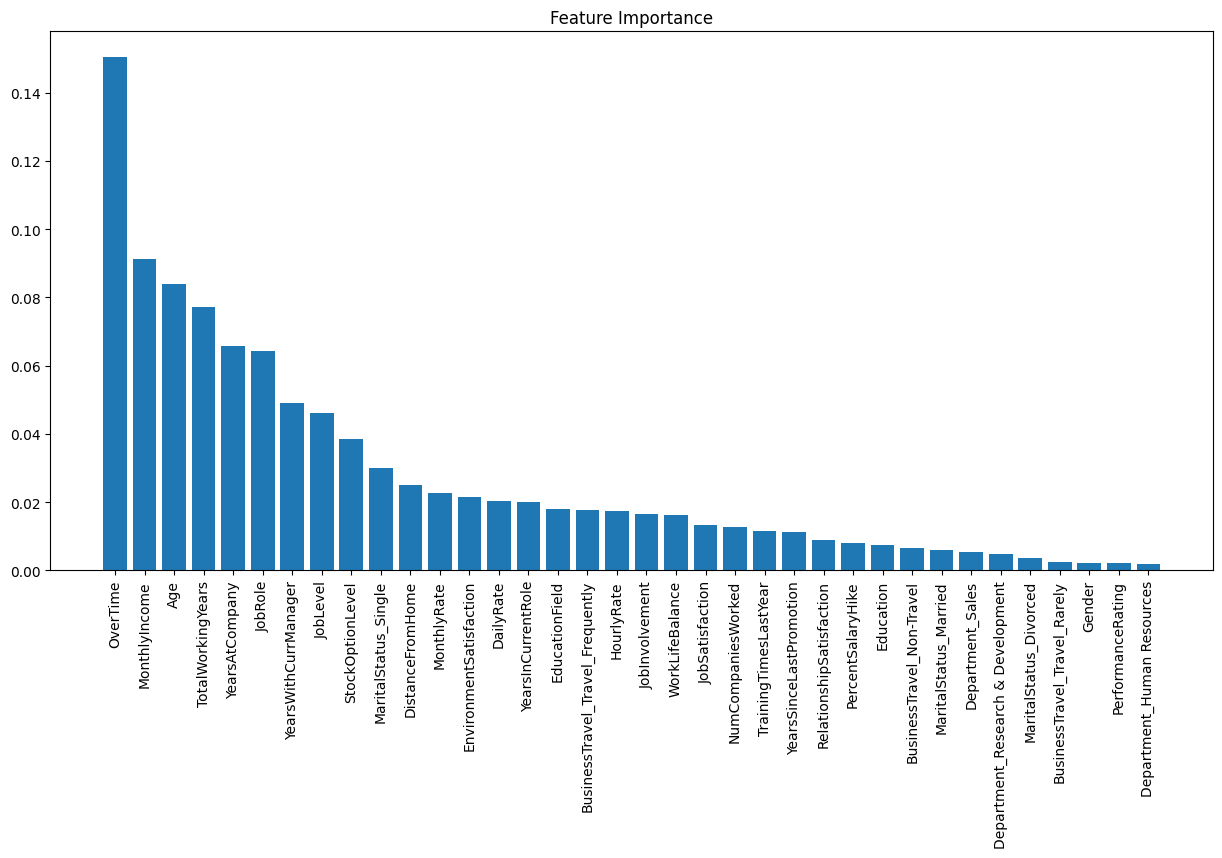

In [16]:
# Feature Importance

import matplotlib.pyplot as plt

rf_clf.fit(X, y)
importances = rf_clf.feature_importances_

indices = np.argsort(importances)[::-1] # Sort feature importances in descending order
names = [X.columns[i] for i in indices] # Rearrange feature names so they match the sorted feature importances

plt.figure(figsize=(15, 7)) # Create plot
plt.title("Feature Importance") # Create plot title
plt.bar(range(X.shape[1]), importances[indices]) # Add bars
plt.xticks(range(X.shape[1]), names, rotation=90) # Add feature names as x-axis labels
plt.show() # Show plot